In [444]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
# sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set path to datasets
DATA_DIR = Path('../src/ose_core/data_ingestion/extracted_datasets')

print("Libraries imported successfully!")


Libraries imported successfully!


In [445]:
# Load KPI data
df_kpi = pd.read_csv(DATA_DIR / '07_kpi_data.csv', dtype={'siren': str, 'siret': str})

print(f"Dataset shape: {df_kpi.shape}")
print(f"\nColumns: {list(df_kpi.columns)}")
display(df_kpi.head(10))

Dataset shape: (3779, 28)

Columns: ['company_name', 'siren', 'siret', 'year', 'fonds_propres', 'ca_france', 'date_cloture_exercice', 'duree_exercice', 'salaires_traitements', 'charges_financieres', 'impots_taxes', 'ca_bilan', 'resultat_exploitation', 'dotations_amortissements', 'capital_social', 'code_confidentialite', 'resultat_bilan', 'annee', 'effectif', 'effectif_sous_traitance', 'filiales_participations', 'evolution_ca', 'subventions_investissements', 'ca_export', 'evolution_effectif', 'participation_bilan', 'ca_consolide', 'resultat_net_consolide']


,company_name,siren,siret,year,fonds_propres,ca_france,date_cloture_exercice,duree_exercice,salaires_traitements,charges_financieres,...,effectif,effectif_sous_traitance,filiales_participations,evolution_ca,subventions_investissements,ca_export,evolution_effectif,participation_bilan,ca_consolide,resultat_net_consolide
0,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2023,2192166.0,6729652.0,2023-01-31,12.0,1394492.0,80993.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2022,1614077.0,6247357.0,2022-01-31,12.0,1327711.0,81469.0,...,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2021,1497114.0,5296275.0,2021-01-31,12.0,1318083.0,66111.0,...,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2020,1577275.0,5710890.0,2020-01-31,12.0,1380952.0,70953.0,...,45.0,18930.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2019,1348804.0,5221375.0,2019-01-31,12.0,1230571.0,88389.0,...,43.0,15835.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2018,1492199.0,NaN,2018-01-31,12.0,1372333.0,385712.0,...,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2017,1419433.0,5630041.0,2017-01-31,12.0,1394179.0,47878.0,...,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2016,NaN,NaN,2016-01-31,12.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2015,NaN,NaN,2015-01-31,12.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2025,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0772,NaN,NaN,NaN,NaN,NaN,NaN


In [446]:
selected_columns = ['company_name', 'siren', 'siret', 'fonds_propres', 'charges_financieres',  'resultat_exploitation', 'resultat_bilan', 'effectif',  'evolution_ca', 'evolution_effectif', 'ca_consolide', 'resultat_net_consolide',  'annee', 'date_cloture_exercice', 'duree_exercice']
mydf_kpi = df_kpi[selected_columns]
mydf_kpi.head(50)


,company_name,siren,siret,fonds_propres,charges_financieres,resultat_exploitation,resultat_bilan,effectif,evolution_ca,evolution_effectif,ca_consolide,resultat_net_consolide,annee,date_cloture_exercice,duree_exercice
0,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2192166.0,80993.0,76546.0,660408.0,NaN,NaN,NaN,NaN,NaN,2023,2023-01-31,12.0
1,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1614077.0,81469.0,65908.0,182001.0,35.0,NaN,NaN,NaN,NaN,2022,2022-01-31,12.0
2,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1497114.0,66111.0,-62109.0,-55121.0,34.0,NaN,NaN,NaN,NaN,2021,2021-01-31,12.0
3,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1577275.0,70953.0,93684.0,253510.0,45.0,NaN,NaN,NaN,NaN,2020,2020-01-31,12.0
4,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1348804.0,88389.0,-247638.0,-118360.0,43.0,NaN,NaN,NaN,NaN,2019,2019-01-31,12.0
5,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1492199.0,385712.0,-47658.0,87770.0,44.0,NaN,NaN,NaN,NaN,2018,2018-01-31,12.0
6,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1419433.0,47878.0,32986.0,81670.0,44.0,NaN,NaN,NaN,NaN,2017,2017-01-31,12.0
7,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,NaN,NaN,NaN,137360.0,NaN,NaN,NaN,NaN,NaN,2016,2016-01-31,12.0
8,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,NaN,NaN,NaN,181450.0,NaN,NaN,NaN,NaN,NaN,2015,2015-01-31,12.0
9,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,NaN,NaN,NaN,NaN,NaN,1.0772,NaN,NaN,NaN,2025,NaN,NaN


In [447]:
mydf_kpi.shape

(3779, 15)

In [448]:
mydf_kpi.isna().sum()


company_name                 0
siren                        0
siret                      215
fonds_propres             1985
charges_financieres       2446
resultat_exploitation     2401
resultat_bilan            1108
effectif                  2143
evolution_ca              3627
evolution_effectif        3701
ca_consolide              3766
resultat_net_consolide    3767
annee                        0
date_cloture_exercice     1144
duree_exercice            1147
dtype: int64

In [449]:
mydf_kpi.isna().mean().sort_values()


company_name              0.000000
siren                     0.000000
annee                     0.000000
siret                     0.056893
resultat_bilan            0.293199
date_cloture_exercice     0.302726
duree_exercice            0.303519
fonds_propres             0.525271
effectif                  0.567081
resultat_exploitation     0.635353
charges_financieres       0.647261
evolution_ca              0.959778
evolution_effectif        0.979360
ca_consolide              0.996560
resultat_net_consolide    0.996825
dtype: float64

In [450]:
mydf_kpi.duplicated().sum()


np.int64(0)

In [451]:
mydf_kpi.duplicated(subset='siren').sum()

np.int64(3405)

In [452]:
mydf_kpi.duplicated(subset=['siren', 'annee']).sum()

np.int64(0)

In [453]:
mydf_kpi.groupby('siren').annee.nunique().sort_values(ascending=False)


siren
332199132    16
339438483    16
519017024    16
419239181    15
521743476    15
             ..
908731821     3
901761114     3
401692801     3
390618890     3
781389002     2
Name: annee, Length: 374, dtype: int64

In [454]:
mydf_kpi.shape

(3779, 15)

In [455]:
kpi_cols = [
    'fonds_propres',
    'charges_financieres',
    'resultat_exploitation',
    'resultat_bilan',
    'effectif',
    'evolution_ca',
    'evolution_effectif',
    'ca_consolide',
    'resultat_net_consolide'
]

# Create a copy
mydf_kpi = mydf_kpi.copy()

# Count how many KPI columns are NOT missing and put in a new column
mydf_kpi.loc[:, 'non_null_kpis'] = mydf_kpi[kpi_cols].notna().sum(axis=1)

mydf_kpi.head(3)

,company_name,siren,siret,fonds_propres,charges_financieres,resultat_exploitation,resultat_bilan,effectif,evolution_ca,evolution_effectif,ca_consolide,resultat_net_consolide,annee,date_cloture_exercice,duree_exercice,non_null_kpis
0,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2192166.0,80993.0,76546.0,660408.0,NaN,NaN,NaN,NaN,NaN,2023,2023-01-31,12.0,4
1,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1614077.0,81469.0,65908.0,182001.0,35.0,NaN,NaN,NaN,NaN,2022,2022-01-31,12.0,5
2,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,1497114.0,66111.0,-62109.0,-55121.0,34.0,NaN,NaN,NaN,NaN,2021,2021-01-31,12.0,5


## Histograms to check: skewness, outliers, heavy tails, different orders of magnitude and sparsity

array([[<Axes: title={'center': 'fonds_propres'}>,
        <Axes: title={'center': 'charges_financieres'}>,
        <Axes: title={'center': 'resultat_exploitation'}>],
       [<Axes: title={'center': 'resultat_bilan'}>,
        <Axes: title={'center': 'effectif'}>,
        <Axes: title={'center': 'evolution_ca'}>],
       [<Axes: title={'center': 'evolution_effectif'}>,
        <Axes: title={'center': 'ca_consolide'}>,
        <Axes: title={'center': 'resultat_net_consolide'}>]], dtype=object)

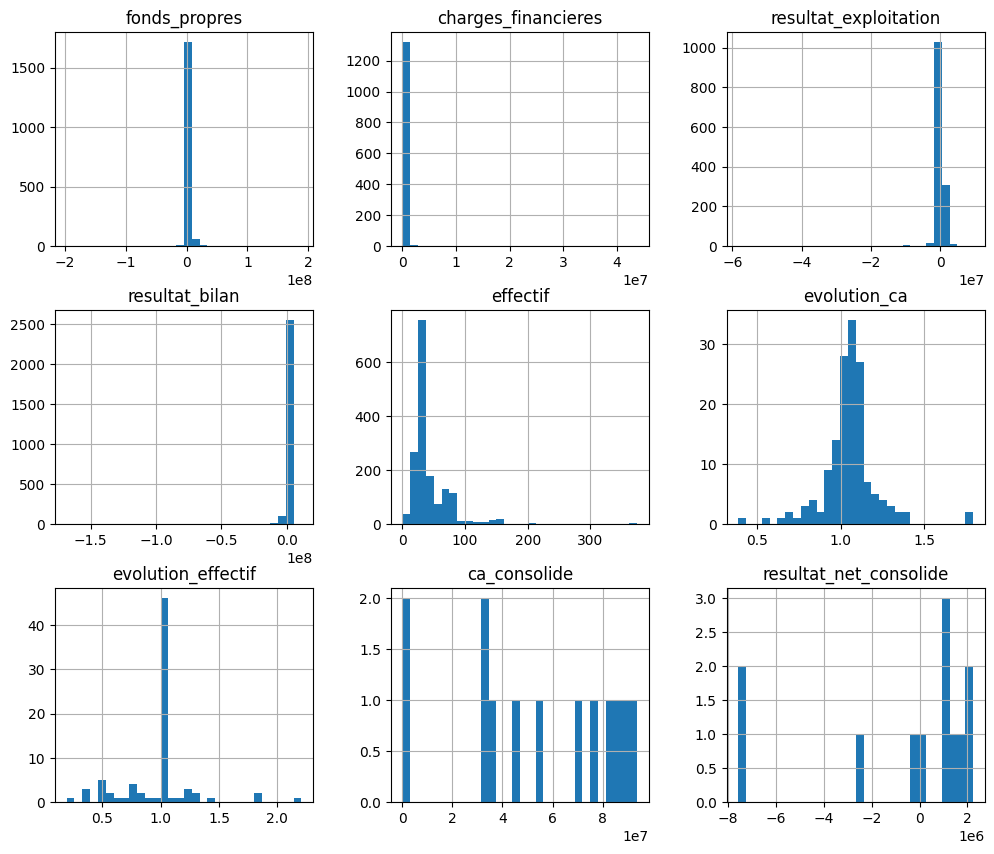

In [456]:
mydf_kpi[kpi_cols].hist(bins=30, figsize=(12,10))


In [457]:
mydf_kpi.shape

(3779, 16)

In [458]:
# Keep only rows with at least 4 KPIs
df_filtered = mydf_kpi.loc[mydf_kpi['non_null_kpis'] >= 4]

df_filtered.shape


(1353, 16)

In [459]:
df_filtered.isna().mean().sort_values()

company_name              0.000000
siren                     0.000000
fonds_propres             0.000000
non_null_kpis             0.000000
annee                     0.000000
date_cloture_exercice     0.000000
duree_exercice            0.000000
resultat_exploitation     0.000739
resultat_bilan            0.012565
charges_financieres       0.019956
siret                     0.058389
effectif                  0.478197
ca_consolide              0.991131
resultat_net_consolide    0.991131
evolution_ca              0.997044
evolution_effectif        1.000000
dtype: float64

In [460]:
df_best_recent = (
    df_filtered
    .sort_values(['siren', 'annee'], ascending=[True, False])
    .groupby('siren')
    .head(1)
    .reset_index(drop=True)
)

In [461]:
df_best_recent.head()

,company_name,siren,siret,fonds_propres,charges_financieres,resultat_exploitation,resultat_bilan,effectif,evolution_ca,evolution_effectif,ca_consolide,resultat_net_consolide,annee,date_cloture_exercice,duree_exercice,non_null_kpis
0,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2192166.0,80993.0,76546.0,660408.0,NaN,NaN,NaN,NaN,NaN,2023,2023-01-31,12.0,4
1,JULIEN MACK,016450298,01645029800043,2187599.0,5346.0,670860.0,453579.0,35.0,NaN,NaN,NaN,NaN,2022,2022-12-31,12.0,5
2,OROC BAT,046580031,04658003100022,2341963.0,19872.0,140333.0,209105.0,35.0,NaN,NaN,NaN,NaN,2023,2023-12-31,12.0,5
3,MINOTERIE DU TRIEVES CORREARD ET FILS,057504649,05750464900013,2558367.0,329745.0,473736.0,78916.0,NaN,NaN,NaN,NaN,NaN,2017,2017-09-30,12.0,4
4,MAISON CANTINI FLANDIN,057821266,05782126600095,6048339.0,33642.0,52265.0,291592.0,NaN,NaN,NaN,NaN,NaN,2021,2021-12-31,12.0,4


In [462]:
df_best_recent["annee"].min()

np.int64(2015)

In [463]:
df_best_recent["annee"].max()

np.int64(2025)

In [464]:
df_best_recent['recency'] = 2025 - df_best_recent['annee']


In [465]:
# Keep companies whose latest KPI year is recent enough
df_recent = df_best_recent.loc[df_best_recent['annee'] >= 2022].copy()

print(df_recent.shape)
df_recent.head()


(133, 17)


,company_name,siren,siret,fonds_propres,charges_financieres,resultat_exploitation,resultat_bilan,effectif,evolution_ca,evolution_effectif,ca_consolide,resultat_net_consolide,annee,date_cloture_exercice,duree_exercice,non_null_kpis,recency
0,PAIN D'EPICES MULOT ET PETITJEAN,015751530,01575153000013,2192166.0,80993.0,76546.0,660408.0,NaN,NaN,NaN,NaN,NaN,2023,2023-01-31,12.0,4,2
1,JULIEN MACK,016450298,01645029800043,2187599.0,5346.0,670860.0,453579.0,35.0,NaN,NaN,NaN,NaN,2022,2022-12-31,12.0,5,3
2,OROC BAT,046580031,04658003100022,2341963.0,19872.0,140333.0,209105.0,35.0,NaN,NaN,NaN,NaN,2023,2023-12-31,12.0,5,2
5,BIRABEN,096780838,09678083800015,1170026.0,8350.0,-64962.0,41927.0,35.0,NaN,NaN,NaN,NaN,2022,2022-12-31,12.0,5,3
7,ATELIERS DE LA QUEILLE,300882131,30088213100018,1690235.0,5294.0,612732.0,383919.0,35.0,NaN,NaN,NaN,NaN,2022,2022-03-31,12.0,5,3


In [466]:
"""
These were removed due to high percentage of missing values:
'evolution_effectif'
'evolution_ca',
'ca_consolide',
'resultat_net_consolide'
'resultat_bilan',
'charges_financieres',
"""

feature_cols = [
    'fonds_propres',
    'resultat_exploitation',
    'effectif',
    'recency'   # giving weight to fresh companies
]

# Keeping only modelling columns + identifiers
cols_to_keep = ['company_name', 'siren'] + feature_cols
df_recent = df_recent[cols_to_keep].copy()

df_recent.head()


,company_name,siren,fonds_propres,resultat_exploitation,effectif,recency
0,PAIN D'EPICES MULOT ET PETITJEAN,015751530,2192166.0,76546.0,NaN,2
1,JULIEN MACK,016450298,2187599.0,670860.0,35.0,3
2,OROC BAT,046580031,2341963.0,140333.0,35.0,2
5,BIRABEN,096780838,1170026.0,-64962.0,35.0,3
7,ATELIERS DE LA QUEILLE,300882131,1690235.0,612732.0,35.0,3


. Companies with ≥4 KPIs
. Most recent year per company (with ≥4 KPIs)
. Recency filter (annee ≥ 2022)
. Median imputation for missing KPIs
. Scaling
. Clustering
. KNN

In [467]:
"""
TEST 1
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')                 #To be verified
X_imputed = imputer.fit_transform(df_recent[feature_cols])

TEST 2
"""

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(df_recent[feature_cols])

"""

df_recent['size_group'] = pd.cut(
    df_recent['effectif'],
    bins=[0, 10, 50, 200, 10000],
    labels=['micro', 'small', 'medium', 'large']
)

# calculate the median of the column per size_group and attribute it
df_recent[feature_cols] = (
    df_recent.groupby('size_group')[feature_cols]
    .transform(lambda x: x.fillna(x.median()))
)

"""

"\n\ndf_recent['size_group'] = pd.cut(\n    df_recent['effectif'],\n    bins=[0, 10, 50, 200, 10000],\n    labels=['micro', 'small', 'medium', 'large']\n)\n\n# calculate the median of the column per size_group and attribute it\ndf_recent[feature_cols] = (\n    df_recent.groupby('size_group')[feature_cols]\n    .transform(lambda x: x.fillna(x.median()))\n)\n\n"

In [468]:
df_recent.columns

Index(['company_name', 'siren', 'fonds_propres', 'resultat_exploitation',
       'effectif', 'recency'],
      dtype='object')

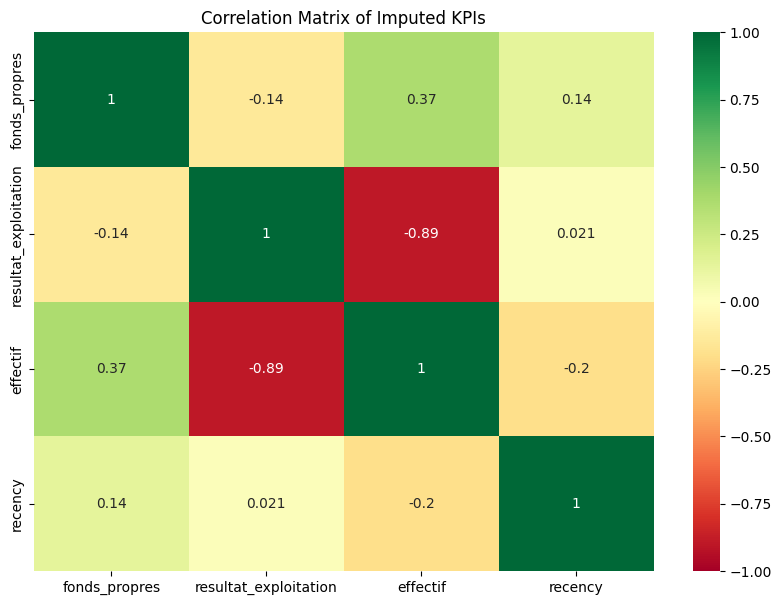

In [ ]:
# Imputed data are already stored in df_recent[feature_cols]
df_imputed = df_recent[feature_cols].copy()

corr = df_imputed.corr()  # compute correlations

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="RdYlGn", annot=True, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Imputed KPIs")
plt.show()


In [470]:
df_recent[feature_cols] = X_imputed


In [471]:
df_recent[['fonds_propres', 'resultat_exploitation', 'effectif']].isna().mean().sort_values()

fonds_propres            0.0
resultat_exploitation    0.0
effectif                 0.0
dtype: float64

In [472]:
"""
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


Financial KPIs, strong outliers, different magnitudes, goal = clustering + PCA + KNN --> Robust Scaler
"""
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled_robust = scaler.fit_transform(X_imputed)
X_scaled_robust


array([[ 6.50049568e-02, -9.57449201e-02, -1.87500000e-01,
         0.00000000e+00],
       [ 6.33769454e-02,  1.01809121e+00, -1.87500000e-01,
         5.00000000e-01],
       [ 1.18403515e-01,  2.38017595e-02, -1.87500000e-01,
         0.00000000e+00],
       [-2.99360167e-01, -3.60952745e-01, -1.87500000e-01,
         5.00000000e-01],
       [-1.13919800e-01,  9.09150371e-01, -1.87500000e-01,
         5.00000000e-01],
       [ 3.98946195e-01, -1.25926863e+00, -1.87500000e-01,
         0.00000000e+00],
       [ 4.63186518e-01,  6.93830659e-02, -1.87500000e-01,
         0.00000000e+00],
       [ 8.92725566e-01,  7.37054279e-01,  2.31250000e+00,
         5.00000000e-01],
       [-7.42069460e-03,  7.06271295e-01, -1.87500000e-01,
         0.00000000e+00],
       [ 1.29294045e+00,  1.04436873e+00,  8.12500000e-01,
         0.00000000e+00],
       [ 4.86700177e-01, -2.19542182e-01, -1.87500000e-01,
        -5.00000000e-01],
       [-1.60936782e-02, -4.98853018e-01, -1.87500000e-01,
      

In [473]:
df_model = df_recent.copy()

# Putting the imputed values back into the dataframe
df_model[feature_cols] = X_imputed


In [474]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled_robust)

df_model['cluster'] = clusters
df_model.head()


,company_name,siren,fonds_propres,resultat_exploitation,effectif,recency,cluster
0,PAIN D'EPICES MULOT ET PETITJEAN,015751530,2192166.0,76546.0,35.0,2.0,4
1,JULIEN MACK,016450298,2187599.0,670860.0,35.0,3.0,4
2,OROC BAT,046580031,2341963.0,140333.0,35.0,2.0,4
5,BIRABEN,096780838,1170026.0,-64962.0,35.0,3.0,4
7,ATELIERS DE LA QUEILLE,300882131,1690235.0,612732.0,35.0,3.0,4


In [475]:
df_model.groupby('cluster')[feature_cols].mean()

,fonds_propres,resultat_exploitation,effectif,recency
cluster,,,,
0,-2.556287e+04,-1.014573e+06,59.017391,1.869565
1,2.303966e+07,-5.829714e+07,375.000000,2.000000
2,-1.972538e+08,1.281941e+06,74.000000,1.000000
3,4.528600e+07,-9.826000e+06,59.000000,3.000000
4,3.193755e+06,3.134411e+05,42.945794,2.233645


## Cluster 0 — Distressed SMEs
fonds_propres → –25k (accumulated losses, technically insolvent) <br>
résultat_exploitation  → –1M (negative result, operational losses) <br>
effectif  → 59 <br>
recency  → 1.8 <br>
PROSPECTABILITY = Very low <br>

## Cluster 1 — Big companies undergoing crisis (huge negative results, heavy operatinal losses)
fonds_propres → +23M <br>
résultat_exploitation  →  –58M <br>
effectif = 375 <br>
PROSPECTABILITY = Low (high risk/restructuring)<br>

## Cluster 2 — Very large negative equity, but positive operating margin (accounting debt but operating profit)
fonds_propres = –197M <br>
résultat_exploitation = +1.2M <br>
effectif = 74 <br>
recency = 1 <br>
PROSPECTABILITY = Medium (high risk, possibly restructuring groups, could be interesting depending on strategy) <br>

## Cluster 3 — Medium companies in difficulty (with operational losses)
fonds_propres = +45M <br>
résultat_exploitation = –9.8M <br>
effectif = 59 <br>
recency = 3
PROSPECTABILITY = Low (high incertitude as outdated data) <br>

## Cluster 4 — Healthy SMEs
fonds_propres = +3M <br>
résultat_exploitation = +313k <br>
effectif = ~43 <br>
data recency ~2.2 <br>
PROSPECTABILITY = High <br>


In [476]:
df_model.groupby('cluster')[feature_cols].mean() - df_model[feature_cols].mean()


,fonds_propres,resultat_exploitation,effectif,recency
cluster,,,,
0,-1.621170e+06,-5.887221e+05,10.441451,-0.295848
1,2.144405e+07,-5.787129e+07,326.424060,-0.165414
2,-1.988494e+08,1.707792e+06,25.424060,-1.165414
3,4.369039e+07,-9.400149e+06,10.424060,0.834586
4,1.598148e+06,7.392921e+05,-5.630145,0.068231


In [477]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_robust)


In [478]:
df_model['PC1'] = X_pca[:, 0]
df_model['PC2'] = X_pca[:, 1]


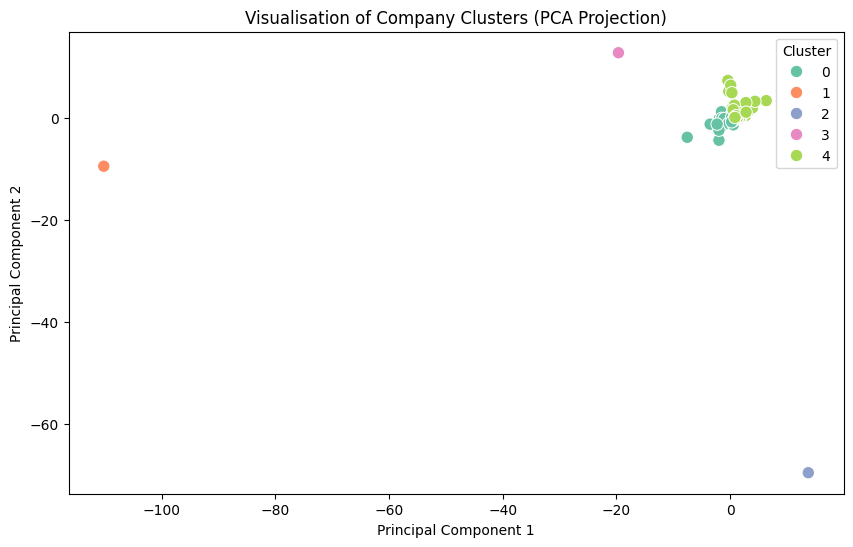

In [479]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_model,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=80
)

plt.title("Visualisation of Company Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


In [480]:
pca.explained_variance_ratio_


array([0.70209203, 0.28907013])

In [481]:
def score_cluster(c):
    # cluster scoring
    if c == 4: return 40
    if c == 2: return 32
    if c == 3: return 20
    if c == 0: return 8
    if c == 1: return 0

def score_equity(fp):
    if fp > 2_000_000: return 10
    elif fp > 1_000_000: return 7
    elif fp > 0: return 4
    else: return 0

def score_exploit(re):
    if re > 300_000: return 10
    elif re > 0: return 6
    elif re > -3_000_000: return 3
    else: return 0

def score_effectif(eff):
    if 30 <= eff <= 200: return 10
    elif 10 <= eff <= 500: return 7
    else: return 3

def score_margin(fp, re):
    margin = re / max(fp, 1)
    if margin > 0.10: return 10
    elif margin > 0.05: return 7
    elif margin > 0: return 4
    else: return 0

def score_recency(r):
    if r == 1: return 10
    if r == 2: return 7
    if r == 3: return 4
    return 1

def compute_total_score(row):
    cluster_s = score_cluster(row['cluster'])
    kpi_s = (
        score_equity(row['fonds_propres']) +
        score_exploit(row['resultat_exploitation']) +
        score_effectif(row['effectif']) +
        score_margin(row['fonds_propres'], row['resultat_exploitation']) +
        5  # growth placeholder
    )
    recency_s = score_recency(row['recency'])
    return cluster_s + kpi_s + recency_s

df_model['score'] = df_model.apply(compute_total_score, axis=1)


In [482]:
top20 = df_model.nlargest(20, 'score')[['company_name', 'siren', 'score', 'cluster']]
bottom20 = df_model.nsmallest(20, 'score')[['company_name', 'siren', 'score', 'cluster']]


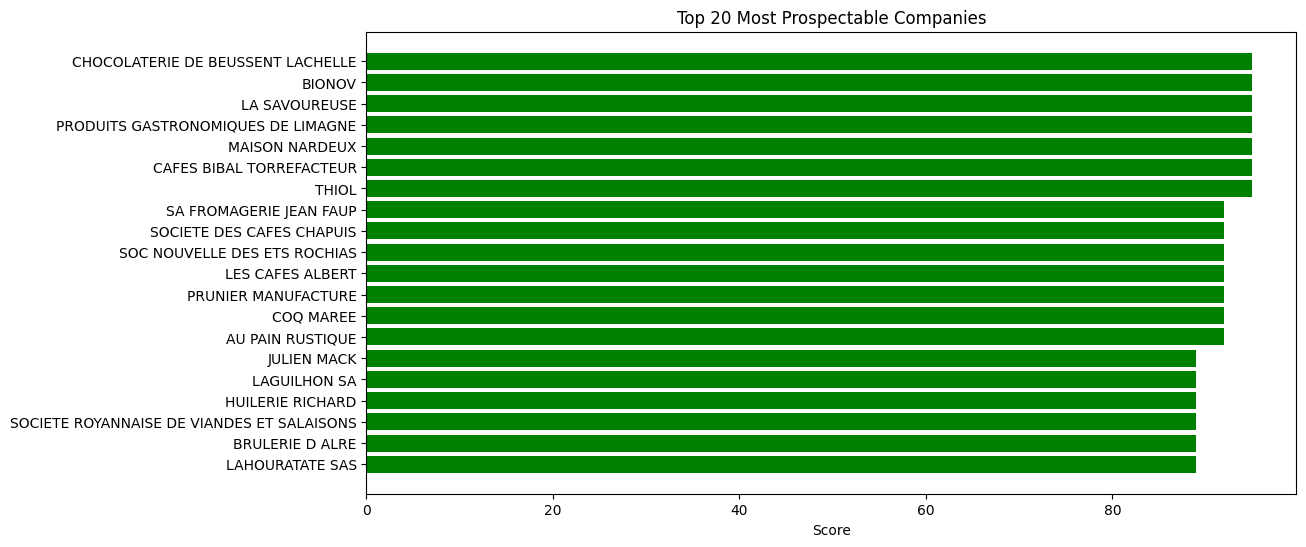

In [483]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(top20['company_name'], top20['score'], color='green')
plt.xlabel("Score")
plt.title("Top 20 Most Prospectable Companies")
plt.gca().invert_yaxis()  # highest score on top
plt.show()


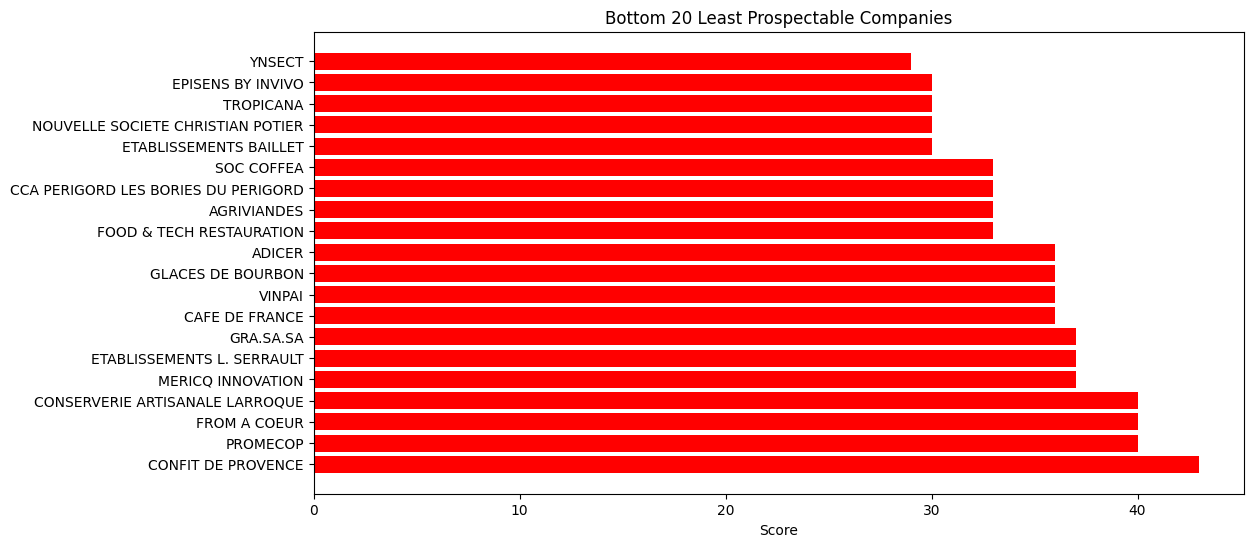

In [484]:
plt.figure(figsize=(12, 6))
plt.barh(bottom20['company_name'], bottom20['score'], color='red')
plt.xlabel("Score")
plt.title("Bottom 20 Least Prospectable Companies")
plt.gca().invert_yaxis()
plt.show()


In [485]:
display(top20)
display(bottom20)


,company_name,siren,score,cluster
66,CHOCOLATERIE DE BEUSSENT LACHELLE,333308278,95,4
102,BIONOV,350675856,95,4
108,LA SAVOUREUSE,353505134,95,4
124,PRODUITS GASTRONOMIQUES DE LIMAGNE,383262631,95,4
176,MAISON NARDEUX,432170579,95,4
227,CAFES BIBAL TORREFACTEUR,519017024,95,4
262,THIOL,736350034,95,4
19,SA FROMAGERIE JEAN FAUP,310336938,92,4
22,SOCIETE DES CAFES CHAPUIS,311974661,92,4
75,SOC NOUVELLE DES ETS ROCHIAS,339438483,92,4


,company_name,siren,score,cluster
238,YNSECT,534948617,29,1
280,EPISENS BY INVIVO,818893281,30,0
281,TROPICANA,828787291,30,0
286,NOUVELLE SOCIETE CHRISTIAN POTIER,884297128,30,0
289,ETABLISSEMENTS BAILLET,897250312,30,0
110,SOC COFFEA,368500815,33,0
120,CCA PERIGORD LES BORIES DU PERIGORD,382102762,33,0
147,AGRIVIANDES,397773946,33,0
290,FOOD & TECH RESTAURATION,908731821,33,0
155,ADICER,408787083,36,0


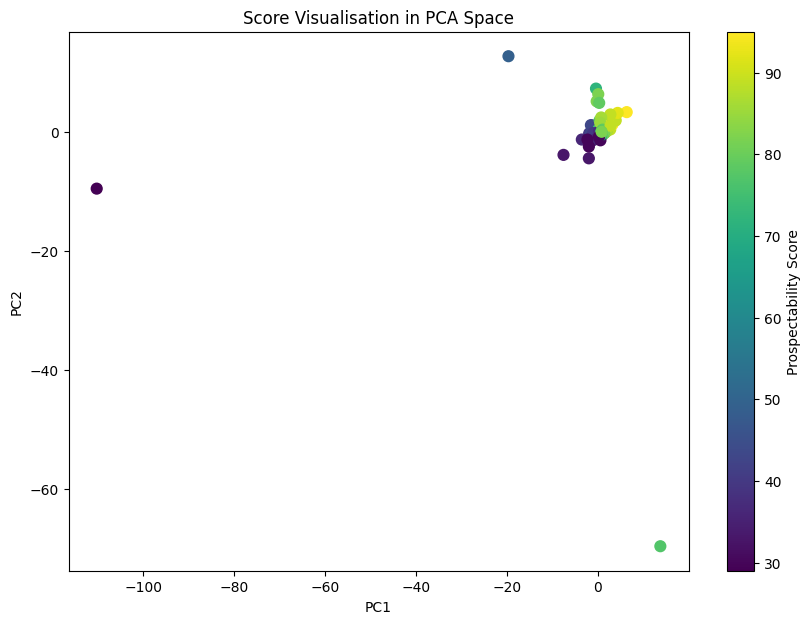

In [486]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(df_model['PC1'], df_model['PC2'],
                      c=df_model['score'], cmap='viridis', s=60)
plt.colorbar(scatter, label="Prospectability Score")
plt.title("Score Visualisation in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
